# Day 6 — Evaluation and Error Analysis

**Lesson focus:** Accuracy, Macro-F1, confusion matrix, and class-level metrics.

**Required evidence:** Write a one-page error analysis.

This notebook evaluates the same TF-IDF + Logistic Regression baseline selected on Day 5. Labels: `0 = factual`, `1 = clickbait`.

## 1. Imports

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

RANDOM_STATE = 42
LABEL_NAMES = {0: 'factual', 1: 'clickbait'}

## 2. Recreate the Day 5 practice dataset

We use the same records and random split so this evaluation matches the Day 5 baseline.

In [2]:
factual_texts = [
    'Government publishes annual budget report',
    'Election commission announces voting schedule',
    'University releases new admission guidelines',
    'Football team wins league match two one',
    'Central bank keeps interest rate unchanged',
    'City council approves road repair project',
    'Hospital opens new emergency care unit',
    'Weather office forecasts rain this weekend',
    'Company reports quarterly revenue growth',
    'School board changes examination schedule',
    'Researchers publish results of health study',
    'Court announces decision in public case',
    'National team names squad for tournament',
    'Airport adds two international flight routes',
    'Ministry releases updated education policy',
    'Local market opens at eight tomorrow',
    'Police issue traffic advisory for festival',
    'Railway announces revised ticket prices',
    'Museum opens exhibition on regional history',
    'Scientists record seasonal river level changes',
]

clickbait_texts = [
    'You will not believe what happened next',
    'This shocking secret has everyone talking',
    'What this celebrity did next stunned fans',
    'The truth they never wanted you to know',
    'Unbelievable moment caught everyone by surprise',
    'This one trick will change your life',
    'Everyone is talking about this shocking reveal',
    'You need to see what happened next',
    'The hidden reason behind this unbelievable story',
    'Fans cannot believe this surprise announcement',
    'What happened next left viewers speechless',
    'This secret detail changes everything',
    'Nobody expected this shocking turn of events',
    'Wait until you see the final result',
    'The real story will completely surprise you',
    'One surprising fact everyone needs to know',
    'This incredible discovery has people amazed',
    'Can you guess what happened after this',
    'The answer will leave you completely shocked',
    'What they found next was truly unbelievable',
]

df = pd.DataFrame({
    'text': factual_texts + clickbait_texts,
    'label': [0] * len(factual_texts) + [1] * len(clickbait_texts),
})
print('Dataset shape:', df.shape)

Dataset shape: (40, 2)


## 3. Reproduce the split and selected baseline

In [3]:
X_train, X_temp, y_train, y_temp = train_test_split(
    df['text'], df['label'], test_size=0.30,
    random_state=RANDOM_STATE, stratify=df['label']
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50,
    random_state=RANDOM_STATE, stratify=y_temp
)

model = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 1), lowercase=True)),
    ('logreg', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])
model.fit(X_train, y_train)

test_pred = model.predict(X_test)
test_probability = model.predict_proba(X_test)[:, 1]

print(f'Train: {len(X_train)} | Validation: {len(X_val)} | Test: {len(X_test)}')

Train: 28 | Validation: 6 | Test: 6


## 4. Accuracy and Macro-F1

- **Accuracy:** fraction of all predictions that are correct.
- **Macro-F1:** calculates F1 separately for each class and averages them equally. This is especially useful when classes are imbalanced.

In [4]:
accuracy = accuracy_score(y_test, test_pred)
macro_f1 = f1_score(y_test, test_pred, average='macro')

summary_metrics = pd.DataFrame({
    'metric': ['Accuracy', 'Macro-F1'],
    'score': [accuracy, macro_f1],
})
summary_metrics

,metric,score
0,Accuracy,0.833333
1,Macro-F1,0.828571


## 5. Confusion matrix

Rows represent actual labels and columns represent predicted labels.

| Position | Meaning |
|---|---|
| Actual factual → Predicted factual | True negative |
| Actual factual → Predicted clickbait | False positive |
| Actual clickbait → Predicted factual | False negative |
| Actual clickbait → Predicted clickbait | True positive |

,Predicted factual,Predicted clickbait
Actual factual,2,1
Actual clickbait,0,3


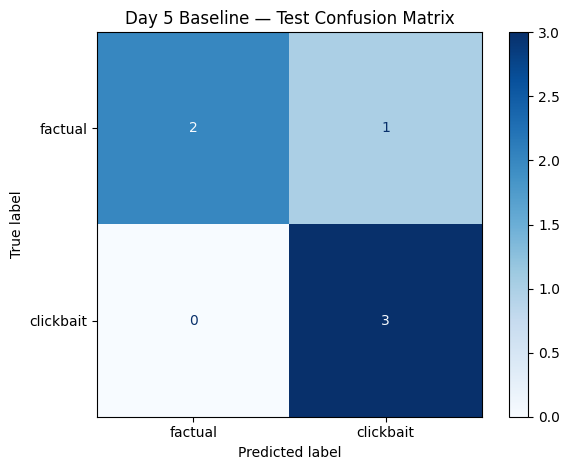

In [5]:
cm = confusion_matrix(y_test, test_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

display(pd.DataFrame(
    cm,
    index=['Actual factual', 'Actual clickbait'],
    columns=['Predicted factual', 'Predicted clickbait'],
))

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['factual', 'clickbait'],
).plot(cmap='Blues', values_format='d')
plt.title('Day 5 Baseline — Test Confusion Matrix')
plt.tight_layout()
plt.show()

## 6. Class-level metrics

Precision, recall, and F1 should be examined for every class—not only as one overall number. `support` is the number of true test examples belonging to that class.

In [6]:
report_dict = classification_report(
    y_test, test_pred,
    target_names=['factual', 'clickbait'],
    output_dict=True, zero_division=0,
)

class_metrics = (
    pd.DataFrame(report_dict).T
    .loc[['factual', 'clickbait'], ['precision', 'recall', 'f1-score', 'support']]
)
class_metrics

,precision,recall,f1-score,support
factual,1.00,0.666667,0.800000,3.0
clickbait,0.75,1.000000,0.857143,3.0


## 7. Inspect every prediction and isolate errors

In [7]:
prediction_df = pd.DataFrame({
    'text': X_test,
    'actual': y_test,
    'predicted': test_pred,
    'clickbait_probability': test_probability,
}).reset_index(drop=True)
prediction_df['actual_name'] = prediction_df['actual'].map(LABEL_NAMES)
prediction_df['predicted_name'] = prediction_df['predicted'].map(LABEL_NAMES)
prediction_df['correct'] = prediction_df['actual'].eq(prediction_df['predicted'])

display(prediction_df[[
    'text', 'actual_name', 'predicted_name',
    'clickbait_probability', 'correct'
]])

errors_df = prediction_df.loc[~prediction_df['correct']].copy()
print('Number of errors:', len(errors_df))
errors_df

,text,actual_name,predicted_name,clickbait_probability,correct
0,Central bank keeps interest rate unchanged,factual,factual,0.469724,True
1,This shocking secret has everyone talking,clickbait,clickbait,0.630633,True
2,The hidden reason behind this unbelievable story,clickbait,clickbait,0.630116,True
3,Researchers publish results of health study,factual,clickbait,0.508476,False
4,This secret detail changes everything,clickbait,clickbait,0.505772,True
5,Hospital opens new emergency care unit,factual,factual,0.394444,True


Number of errors: 1


,text,actual,predicted,clickbait_probability,actual_name,predicted_name,correct
3,Researchers publish results of health study,0,1,0.508476,factual,clickbait,False


## 8. Explain the error using the model's known vocabulary

A TF-IDF model cannot use words that were absent from its training vocabulary. We inspect which words from the misclassified sentence were actually recognized.

In [8]:
vectorizer = model.named_steps['tfidf']
classifier = model.named_steps['logreg']
feature_names = vectorizer.get_feature_names_out()

error_explanations = []
for _, row in errors_df.iterrows():
    vector = vectorizer.transform([row['text']])
    known_terms = [feature_names[index] for index in vector.indices]
    contributions = [
        {
            'term': feature_names[index],
            'contribution_toward_clickbait': float(value * classifier.coef_[0, index]),
        }
        for index, value in zip(vector.indices, vector.data)
    ]
    error_explanations.append({
        'text': row['text'],
        'known_terms': known_terms,
        'term_contributions': contributions,
        'clickbait_probability': float(row['clickbait_probability']),
    })

error_explanations

[{'text': 'Researchers publish results of health study',
  'known_terms': ['of'],
  'term_contributions': [{'term': 'of',
    'contribution_toward_clickbait': 0.15515986108358454}],
  'clickbait_probability': 0.5084757192188144}]

## 9. Required evidence — one-page error analysis

The following cell writes a concise Markdown report to `../results/day_06_error_analysis.md`.

In [9]:
error_text = errors_df.iloc[0]['text'] if len(errors_df) else 'No test errors'
error_probability = (
    float(errors_df.iloc[0]['clickbait_probability']) if len(errors_df) else 0.0
)
known_terms_text = (
    ', '.join(f'`{term}`' for term in error_explanations[0]['known_terms'])
    if error_explanations else 'Not applicable'
)

analysis_report = f'''# Day 6 — Classical Baseline Error Analysis

## Evaluation summary

The TF-IDF + Logistic Regression baseline was evaluated on an untouched test set of {len(y_test)} texts: {int((y_test == 0).sum())} factual and {int((y_test == 1).sum())} clickbait. It correctly classified {int((test_pred == y_test).sum())} of {len(y_test)} examples, producing an accuracy of {accuracy:.3f} and a Macro-F1 of {macro_f1:.3f}. Macro-F1 is slightly lower because it gives equal weight to both classes and the factual class performed less strongly. Because this test set is extremely small, these scores are suitable for workflow practice but not for a reliable real-world performance claim.

## Confusion-matrix findings

The confusion matrix contains {tn} true negatives, {fp} false positive, {fn} false negatives, and {tp} true positives. The model detected all {tp} clickbait examples, so clickbait recall was {class_metrics.loc['clickbait', 'recall']:.3f}. However, one factual example was incorrectly flagged as clickbait. Consequently, factual recall was {class_metrics.loc['factual', 'recall']:.3f}, while clickbait precision fell to {class_metrics.loc['clickbait', 'precision']:.3f}. In this sample, the model was therefore slightly more willing to predict clickbait than to miss it.

## Misclassified example

The only error was: **“{error_text}”**. Its true class was factual, but the model assigned a clickbait probability of {error_probability:.3f}, only slightly above the 0.50 decision threshold. This is a borderline prediction rather than a confident failure. Of the sentence's meaningful words, most were absent from the small training vocabulary. The recognized term was {known_terms_text}. That term had a small positive contribution toward clickbait, leaving the classifier without enough learned factual evidence to make the correct decision.

## Likely cause and next actions

The main limitation is data sparsity: only 28 training texts and 6 test texts were used. The model cannot learn dependable weights for varied factual vocabulary such as research, health, and study when those terms do not occur in training. The next experiment should use a larger, more diverse dataset; retain stratified splitting; inspect false positives and false negatives separately; and compare word n-grams with character n-grams. Performance should then be reported with class-level precision, recall, F1, support, and Macro-F1—not accuracy alone.
'''

results_dir = Path('../results')
results_dir.mkdir(parents=True, exist_ok=True)
report_path = results_dir / 'day_06_error_analysis.md'
report_path.write_text(analysis_report, encoding='utf-8')

print('Error analysis saved to:', report_path)
print(analysis_report)

Error analysis saved to: ../results/day_06_error_analysis.md
# Day 6 — Classical Baseline Error Analysis

## Evaluation summary

The TF-IDF + Logistic Regression baseline was evaluated on an untouched test set of 6 texts: 3 factual and 3 clickbait. It correctly classified 5 of 6 examples, producing an accuracy of 0.833 and a Macro-F1 of 0.829. Macro-F1 is slightly lower because it gives equal weight to both classes and the factual class performed less strongly. Because this test set is extremely small, these scores are suitable for workflow practice but not for a reliable real-world performance claim.

## Confusion-matrix findings

The confusion matrix contains 2 true negatives, 1 false positive, 0 false negatives, and 3 true positives. The model detected all 3 clickbait examples, so clickbait recall was 1.000. However, one factual example was incorrectly flagged as clickbait. Consequently, factual recall was 0.667, while clickbait precision fell to 0.750. In this sample, the model was

## 10. Verification

In [10]:
assert cm.shape == (2, 2)
assert int(cm.sum()) == len(y_test)
assert tn == 2 and fp == 1 and fn == 0 and tp == 3
assert len(errors_df) == 1
assert 0.0 <= accuracy <= 1.0
assert 0.0 <= macro_f1 <= 1.0
assert report_path.exists()
assert 'Misclassified example' in analysis_report

print('All Day 6 evaluation and error-analysis checks passed successfully!')

All Day 6 evaluation and error-analysis checks passed successfully!


## Independent practice

1. Explain the difference between a false positive and a false negative in clickbait detection.
2. Explain why accuracy and Macro-F1 are different here.
3. Decide which error would be more harmful for your own application: falsely flagging factual news or missing clickbait.
4. Add at least 20 new examples per class and rerun the evaluation.
5. Compare word TF-IDF with `analyzer='char_wb', ngram_range=(3, 5)`.